In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
from torch.utils.data import Dataset
import transformers
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer

from meft import MeftConfig, MeftTrainer



/root/miniconda3/lib/python3.12/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# model_name = "Qwen/Qwen2.5-0.5B-Instruct"
# model_name = "Qwen/Qwen2.5-3B-Instruct"
# model_name = "Qwen/Qwen2.5-7B-Instruct"
model_name = "Qwen/Qwen3-0.6B-Base"
# model_name = "Qwen/Qwen3-1.7B-Base"
# model_name = "Qwen/Qwen3-4B-Base"
# model_name = "Qwen/Qwen3-8B-Base"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    # quantization_config=BitsAndBytesConfig(  
    #     load_in_8bit=True,
    # ),
    # attn_implementation="flash_attention_2",
    device_map="auto",
)

In [3]:
class RandomDataset(Dataset):
    def __init__(self, seq_len):
        super().__init__()
        self.seq_len = seq_len
    def __len__(self):
        return 1000
    def __getitem__(self, index):
        return {"input_ids": torch.randint(0, 10000, (self.seq_len,)).tolist()}

seq_len = 512
dataset = RandomDataset(seq_len)

In [4]:
# peft_config = LoraConfig(
#     r=8,
#     lora_alpha=16,
#     lora_dropout=0.1,
#     target_modules=["q_proj", "v_proj"],
#     bias="none",
#     task_type="CAUSAL_LM",
# )

# model = get_peft_model(model, peft_config)
# model.print_trainable_parameters()

In [5]:
trainer = MeftTrainer[SFTTrainer](
    model=model,
    args=SFTConfig(
        per_device_train_batch_size=16,
        gradient_accumulation_steps=1,
        num_train_epochs=1,
        save_strategy="no",
        bf16=True,
        report_to="none",
        # max_seq_length=seq_len,
        dataset_kwargs={"skip_prepare_dataset": True},
    ),
    train_dataset=dataset,
   meft_config=MeftConfig(
        patch_locations=("ckpt_layer",),
        compress_kwargs={"rank": 0.125},
    ),
)

Applying patch to qwen3 model in: ('ckpt_layer',)


In [6]:
trainer.train()

Setting `use_cache=False` during training.


Step,Training Loss
10,10.670200
20,10.279800
30,10.196500
40,10.150600
50,10.137300
60,10.136300


TrainOutput(global_step=63, training_loss=10.255902426583427, metrics={'train_runtime': 40.5854, 'train_samples_per_second': 24.639, 'train_steps_per_second': 1.552, 'total_flos': 1353116024832000.0, 'train_loss': 10.255902426583427})

In [7]:
memory_model = sum(p.numel() * p.element_size() for p in trainer.model.parameters())
memory_grad = sum(p.numel() * p.element_size() for p in trainer.optimizer.param_groups[0]['params'])
memory_optim = memory_grad * 2
max_memory_allocated = torch.cuda.max_memory_allocated("cuda:0")
max_memory_reserved = torch.cuda.max_memory_reserved("cuda:0")
memory_activation = max_memory_allocated - memory_model - memory_grad - memory_optim
print(f"Max memory reserved: {max_memory_reserved / (1024**2):.0f} MB")
print(f"Max memory allocated: {max_memory_allocated / (1024**2):.0f} MB")
print(f"Model: {memory_model / (1024**2):.0f} MB")
print(f"Gradient: {memory_grad / (1024**2):.0f} MB")
print(f"Optimizer: {memory_optim / (1024**2):.0f} MB")
print(f"Activation: {memory_activation / (1024**2):.0f} MB")

Max memory reserved: 22894 MB
Max memory allocated: 17799 MB
Model: 1137 MB
Gradient: 1137 MB
Optimizer: 2274 MB
Activation: 13251 MB


In [8]:
# exit(0)

In [9]:
class ProfCallback(TrainerCallback):
    def __init__(self, prof):
        self.prof = prof

    def on_step_end(self, args, state, control, **kwargs):
        self.prof.step()

Setting `use_cache=False` during training.


Step,Training Loss
10,10.115600
20,10.077600
30,10.047500
40,10.034500
50,10.029300
60,10.024000


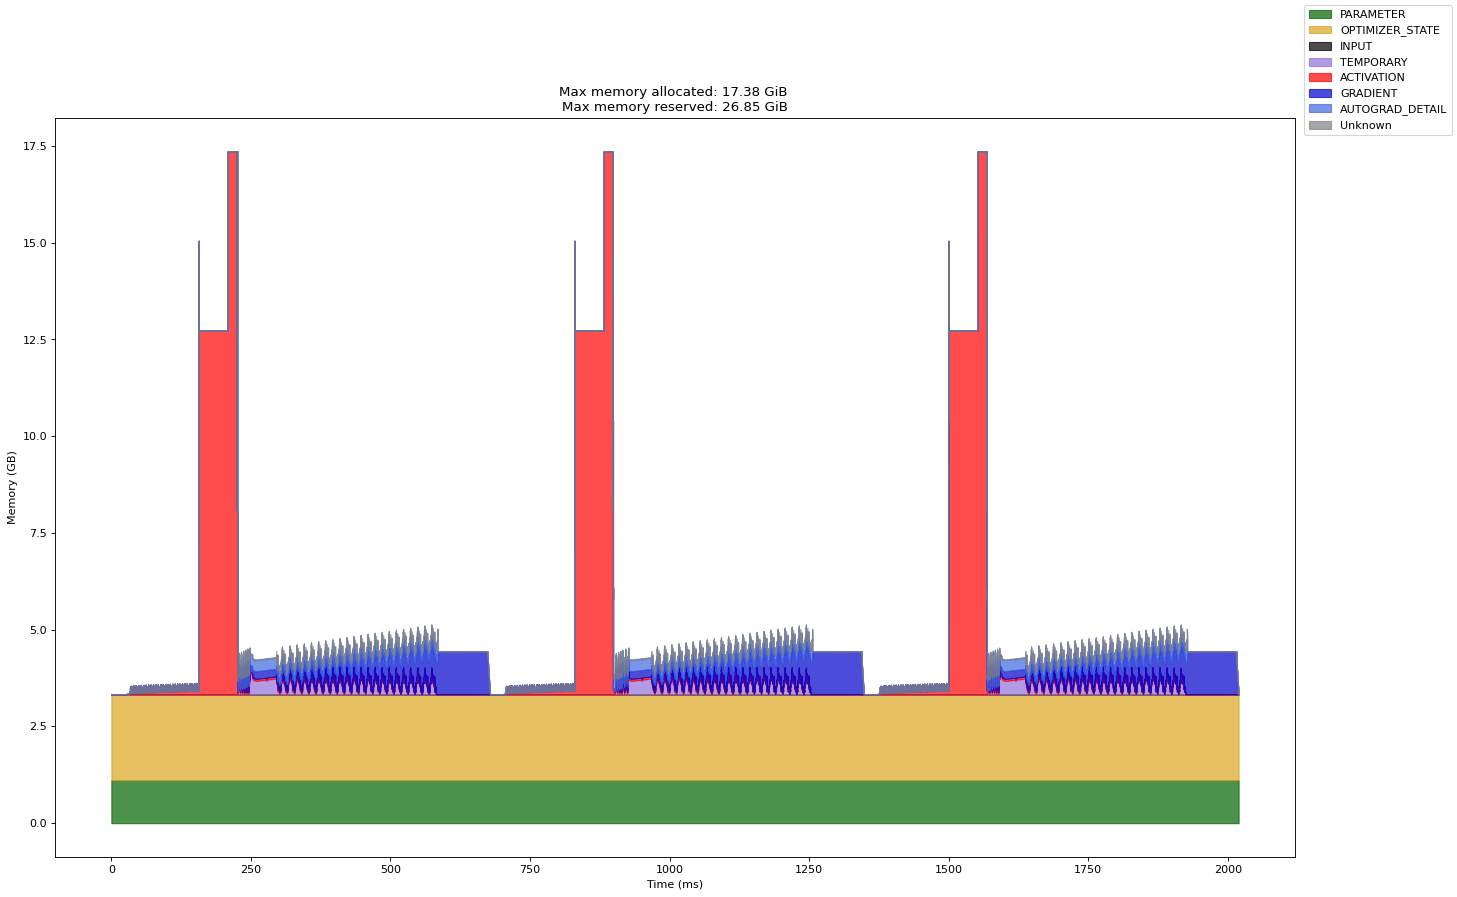

In [10]:
import logging
import socket
from datetime import datetime, timedelta

import torch
from torch.autograd.profiler import record_function

logging.basicConfig(
   format="%(levelname)s:%(asctime)s %(message)s",
   level=logging.INFO,
   datefmt="%Y-%m-%d %H:%M:%S",
)
logger: logging.Logger = logging.getLogger(__name__)
logger.setLevel(level=logging.INFO)

TIME_FORMAT_STR: str = "%b_%d_%H_%M_%S"

# Prefix for file names.
host_name = socket.gethostname()
timestamp = datetime.now().strftime(TIME_FORMAT_STR)
file_prefix = f"{host_name}_{timestamp}"

def trace_handler(prof: torch.profiler.profile):

   # Construct the trace file.
   # prof.export_chrome_trace(f"{file_prefix}.json.gz")

   # Construct the memory timeline file.
   prof.export_memory_timeline(f"./profiler/{file_prefix}.html", device="cuda:0")
   prof.export_memory_timeline(f"./profiler/{file_prefix}.json", device="cuda:0")


with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
    schedule=torch.profiler.schedule(skip_first=3, wait=1, warmup=1, active=3, repeat=1),
    profile_memory=True,
    with_stack=True,
    record_shapes=True,
    on_trace_ready=trace_handler,
) as prof:
    trainer.add_callback(ProfCallback(prof=prof))
    trainer.train()

In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt
from torch.profiler._memory_profiler import _CATEGORY_TO_COLORS, _CATEGORY_TO_INDEX

with open(f"./profiler/{file_prefix}.json", "r") as f:
# with open(f"./profiler/shijx-3090_Jul_13_04_23_54.json", "r") as f:
    mt = json.load(f)

times, sizes = np.array(mt[0]), np.array(mt[1])
t_min = min(times)
times -= t_min

Category.PARAMETER 1.110231876373291
Category.OPTIMIZER_STATE 2.2204601392149925
Category.INPUT 0.0002529621124267578
Category.TEMPORARY 0.6887826919555664
Category.ACTIVATION 14.0255446434021
Category.GRADIENT 1.1102428436279297
Category.AUTOGRAD_DETAIL 9.2734375
None 0.10944175720214844
17.36533447355032


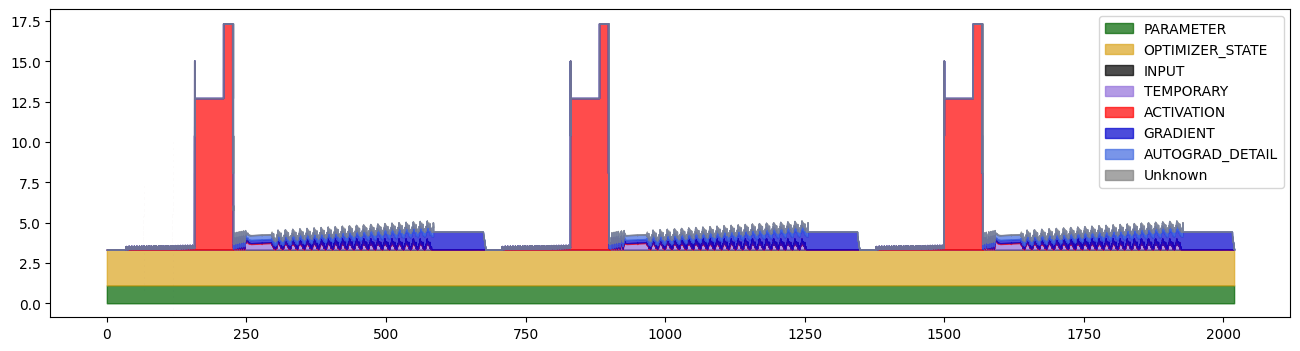

In [12]:
stacked = np.cumsum(sizes, axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for category, color in _CATEGORY_TO_COLORS.items():
    i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i in _CATEGORY_TO_COLORS])

for category, color in _CATEGORY_TO_COLORS.items():
    i = _CATEGORY_TO_INDEX[category]
    print(category, (stacked[:, i+1] - stacked[:, i]).max())

print(stacked[:, -1].max())

1.110231876373291
1.1102294921875


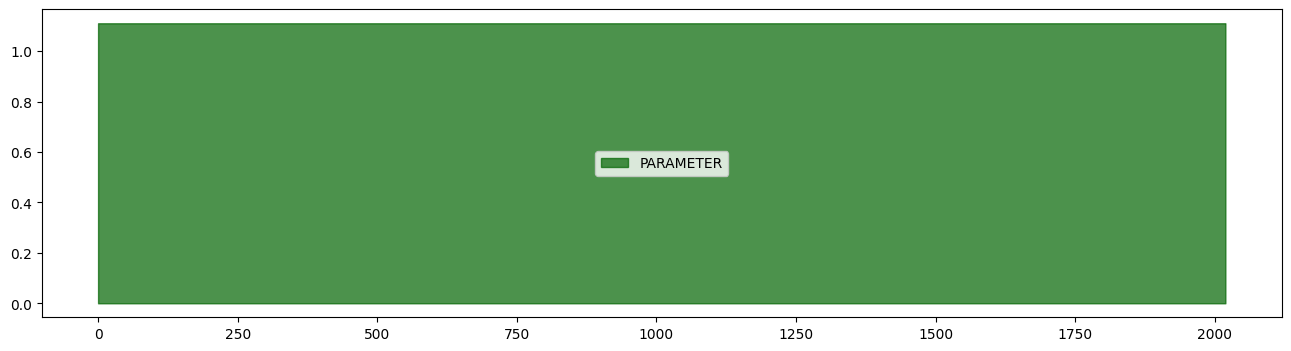

In [13]:
k = (0,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())
print(stacked[:, -1].min())

2.2204601392149925
2.2204601392149925


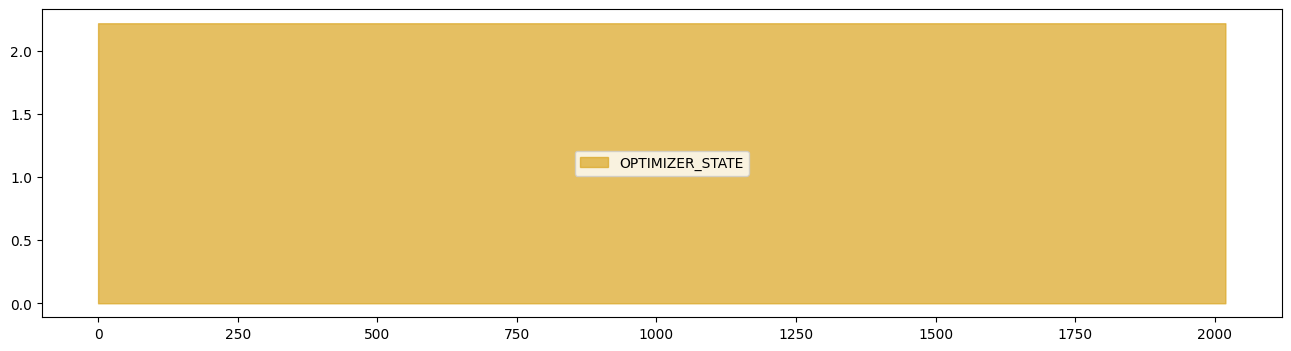

In [14]:
k = (1,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())
print(stacked[:, -1].min())

0.0002529621124267578
2.384185791015625e-07


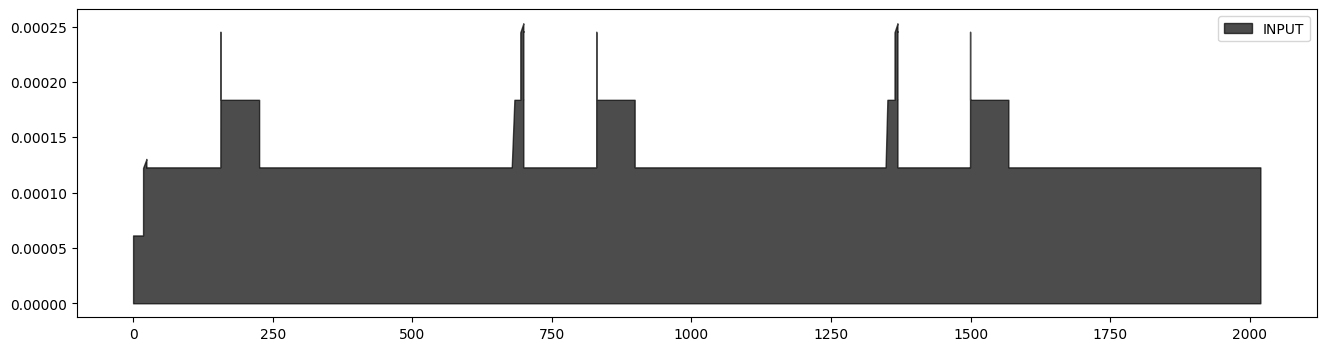

In [15]:
k = (2,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())
print(stacked[:, -1].min())

14.0255446434021


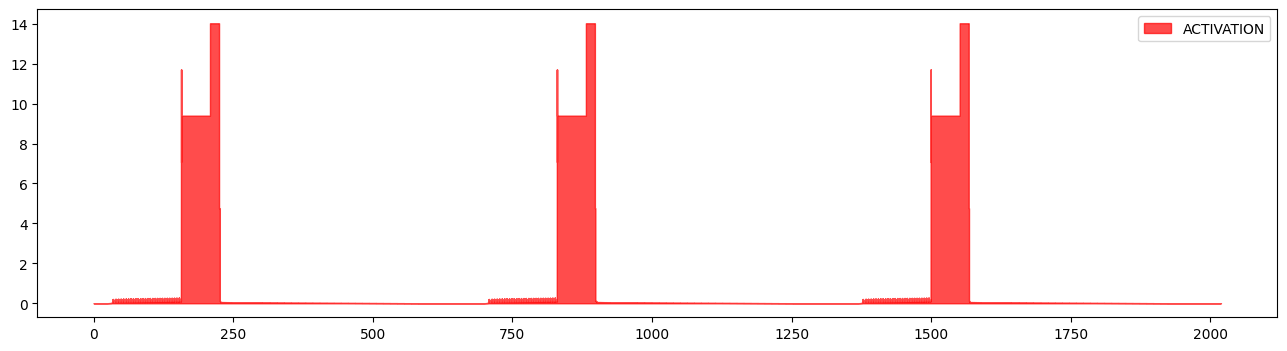

In [16]:
k = (4,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())

0.7044739723205566


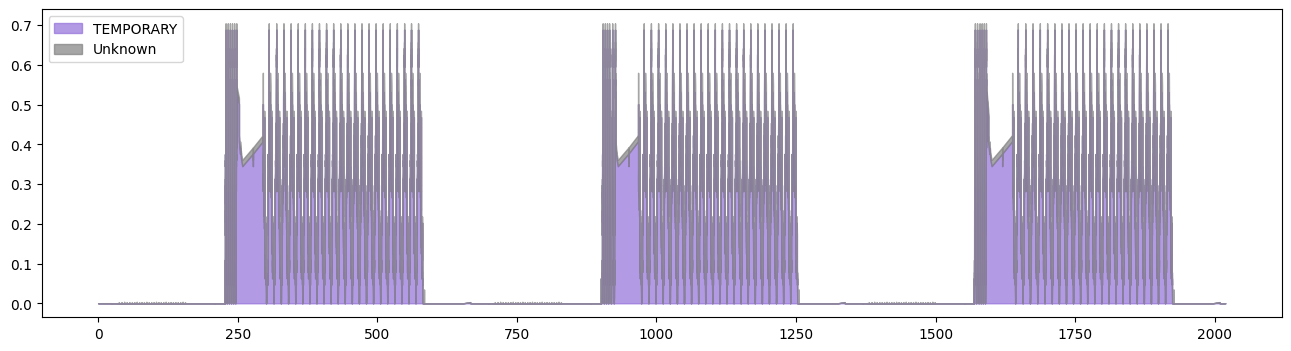

In [17]:
k = (3,7,)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())

9.2734375


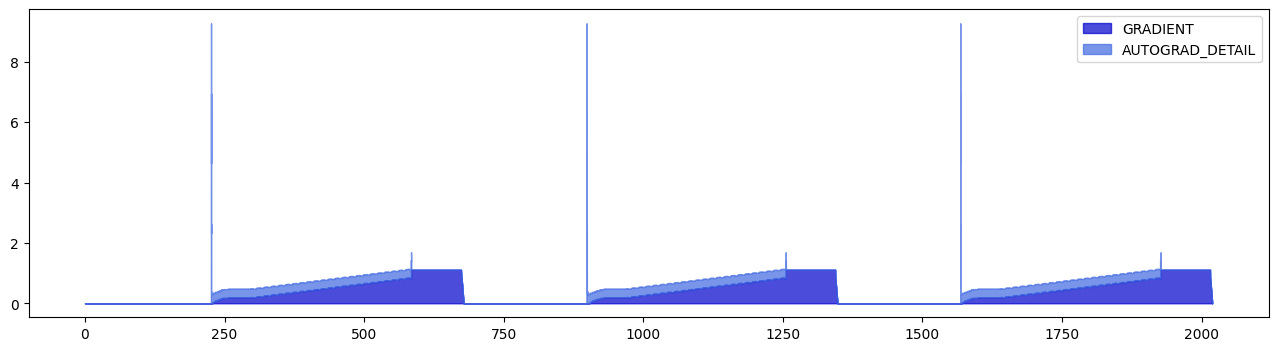

: 

In [ ]:
k = (5,6)
items = [list(_CATEGORY_TO_COLORS.items())[i] for i in k]
stacked = np.cumsum(sizes[:, (0, *(i+1 for i in k))], axis=1) / 1024**3

plt.figure(figsize=(16, 4))
for i, (category, color) in enumerate(items):
    # i = _CATEGORY_TO_INDEX[category]
    plt.fill_between(
        times / 1e3, stacked[:, i], stacked[:, i + 1], color=color, alpha=0.7
    )
plt.legend(["Unknown" if i is None else i.name for i, _ in items])

print(stacked[:, -1].max())